## p3482_o28250: Variants in CFTR gene in Peanuta Allergy Patients

In [96]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from scipy import stats
warnings.filterwarnings("ignore")

In [64]:
##import table and check the column names and data types
table = pd.read_csv("final.summary.table.clinvar.txt", sep = "\t")
print(table.dtypes)

CHROM                                 int64
POS                                   int64
REF                                  object
ALT                                  object
AF_inPA                              object
Heterozygosity                       object
ANN[*].EFFECT                        object
ANN[*].GENE                          object
ANN[*].HGVS_C                        object
ANN[*].HGVS_P                        object
GEN[*].GT                            object
CLNSIG[*]                            object
filter_gnomad                        object
AC_gnomad                            object
AN_gnomad                            object
AF_gnomad                            object
InbreedingCoeff_gnomad               object
MQ_gnomad                            object
QD_gnomad                            object
ReadPosRankSum_gnomad                object
VarDP_gnomad                         object
AS_VQSLOD_gnomad                     object
AC_popmax_gnomad                

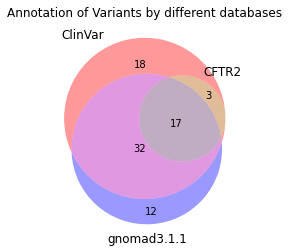

In [65]:
##Check how many SNPs from the database are annotated by clinvar (any effect), 
### have gnomad AF from non-finish europeans,
### have CFTR2 database annotation

table["POS"] = table.POS.apply(lambda x: str(x))
A = set(table[table["CLNSIG[*]"] != "."]["POS"])
B = set(table[table["Variant_final_determination_29.04"] != "."]["POS"])
C = set(table[table["AF_nfe_gnomad"] != "."]["POS"])
from matplotlib_venn import venn3
venn3([A, B, C], ('ClinVar', 'CFTR2', 'gnomad3.1.1'))
plt.title("Annotation of Variants by different databases")
plt.savefig("Variant_Annotation_Different_DB.pdf")

In [66]:
## Subsample the original table only restricting to variants that have a gnomad allele frequency 
### entry from non-finish europeans

table_sub1 = table[table["AF_nfe_gnomad"] != "."] \
[['CHROM', 'POS', 'REF', 'ALT', "GEN[*].GT", "ANN[*].HGVS_C", 'AF_inPA', 'Heterozygosity','AF_gnomad', \
  'InbreedingCoeff_gnomad', 'AF_nfe_gnomad','Allele_frequency_in_CFTR2']]
table_sub1.dtypes

CHROM                         int64
POS                          object
REF                          object
ALT                          object
GEN[*].GT                    object
ANN[*].HGVS_C                object
AF_inPA                      object
Heterozygosity               object
AF_gnomad                    object
InbreedingCoeff_gnomad       object
AF_nfe_gnomad                object
Allele_frequency_in_CFTR2    object
dtype: object

In [67]:
## Adjust the datatable to change object types into numbers
table_sub1 = table_sub1.drop_duplicates()
table_sub1["Allele_frequency_in_CFTR2"] = table_sub1["Allele_frequency_in_CFTR2"] \
.apply(lambda x: float(x) if x != "." else np.NaN)
table_sub1["AF_inPA"] = table_sub1["AF_inPA"].apply(lambda x: float(x))
table_sub1["Heterozygosity"] = table_sub1["Heterozygosity"].apply(lambda x: float(x))
table_sub1["AF_gnomad"] = table_sub1["AF_gnomad"].apply(lambda x: float(x))
table_sub1["InbreedingCoeff_gnomad"] = table_sub1["InbreedingCoeff_gnomad"].apply(lambda x: float(x))
table_sub1["AF_nfe_gnomad"] = table_sub1["AF_nfe_gnomad"].apply(lambda x: float(x))
table_sub1.dtypes

CHROM                          int64
POS                           object
REF                           object
ALT                           object
GEN[*].GT                     object
ANN[*].HGVS_C                 object
AF_inPA                      float64
Heterozygosity               float64
AF_gnomad                    float64
InbreedingCoeff_gnomad       float64
AF_nfe_gnomad                float64
Allele_frequency_in_CFTR2    float64
dtype: object

In [68]:
## Only take out allele frequency from the subsampled table and prepare the table for plotting

table_AF = table_sub1[['CHROM', 'ANN[*].HGVS_C', 'AF_inPA', 'AF_nfe_gnomad', 'Allele_frequency_in_CFTR2']]
table_AF = pd.melt(table_AF, id_vars = ["CHROM", "ANN[*].HGVS_C"]).rename({"variable" : "Data source"}, axis = 1) \
.replace({"AF_inPA" : "PA", "AF_nfe_gnomad" : "NFE_gnomad3.1.1", "Allele_frequency_in_CFTR2": "CFTR2"})

In [69]:
#calculate cumulative allele frequency by adding all frequencies and subtracting them by number of variants
cumulative_AF = \
table_sub1[['AF_inPA','AF_gnomad','AF_nfe_gnomad', 'Allele_frequency_in_CFTR2']].agg("sum").reset_index()
cumulative_AF[1] = cumulative_AF[0].apply(lambda x: x/61)
cumulative_AF.rename({1: "cumulative_AF"}, axis = 1)

,index,0,cumulative_AF
0,AF_inPA,2.446754,0.040111
1,AF_gnomad,2.504744,0.041061
2,AF_nfe_gnomad,2.001991,0.032820
3,Allele_frequency_in_CFTR2,0.738670,0.012109


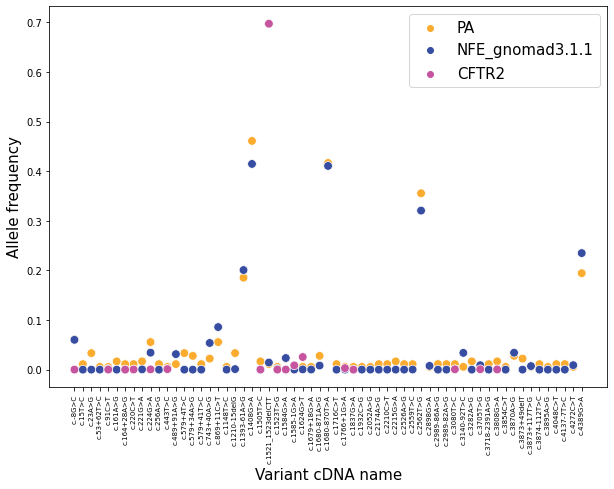

In [70]:
## Plot allele frequencies for each variant, label each variant according to their cDNA name
plt.figure(figsize=(10,7))
color_scheme = ["#FBAC2F","#374DA1","#C7549F"]
sns.scatterplot("ANN[*].HGVS_C", "value", hue = "Data source", data = table_AF, palette=color_scheme, s = 75)
plt.xticks(rotation=90, size = 7)
plt.yticks(size = 10)
plt.ylabel("Allele frequency", size = 15)
plt.xlabel("Variant cDNA name", size = 15)
plt.legend(fontsize = 15)

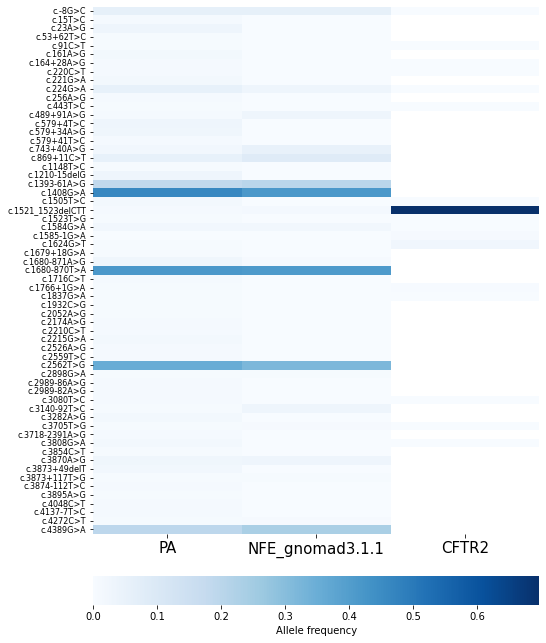

In [71]:
## Display allele frequency as a heatmap

grid_kws = {"height_ratios": (.9, .05), "hspace": .15}
f, (ax, cbar_ax) = plt.subplots(2, gridspec_kw=grid_kws, figsize=(8,11))
ax = sns.heatmap(table_sub1[['AF_inPA', 'AF_nfe_gnomad', 'Allele_frequency_in_CFTR2']], \
                 ax = ax, yticklabels=table_sub1["ANN[*].HGVS_C"], cmap="Blues", \
                 xticklabels = ["PA", "NFE_gnomad3.1.1", "CFTR2"], cbar_ax=cbar_ax, \
                 cbar_kws={"orientation": "horizontal",'label': 'Allele frequency', })
ax.yaxis.set_tick_params(labelsize=8)
ax.xaxis.set_tick_params(labelsize=15)
cbar_ax.tick_params(labelsize=10) 
plt.savefig("Heatmap_AF.pdf", bbox_inches='tight')

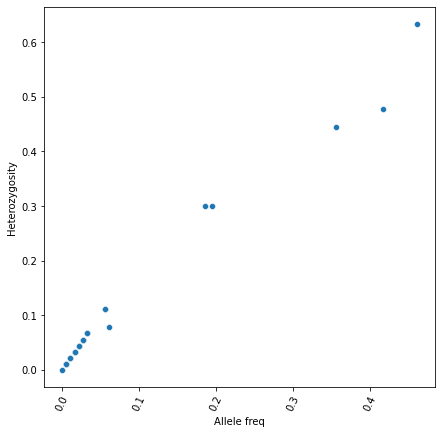

In [72]:
## Check if allele frequency correlates with heterozygosity
plt.figure(figsize=(7,7))
sns.scatterplot("AF_inPA", "Heterozygosity", data = table_sub1)
plt.xticks(rotation=65)
plt.ylabel("Heterozygosity")
plt.xlabel("Allele freq")
plt.savefig("AF_vs_Heterozygosity.pdf")

In [73]:
## Create a table to calculate number of variants per individual patient
## Divide them into homozygous variants for alternative allele and heterozygous variants

genotype_table = table_sub1['GEN[*].GT'].str.split(',', 93, expand=True)

list_of_genotypes = []
for i in range(0,93):
    list_of_genotypes = list_of_genotypes + genotype_table[i].unique().tolist()
    list_of_genotypes = list(set(list_of_genotypes))

counts_of_variants = pd.DataFrame(list_of_genotypes)

for j in range(0,genotype_table.shape[1]):
        x = []
        for i in range(0,genotype_table.shape[0]):
            x.append(genotype_table.to_numpy()[i][j])
        unique, counts = np.unique(x, return_counts=True)
        Z = "PA" + "_" + str(j+1)
        y = np.asarray((unique, counts)).T
        counts_of_variants = pd.merge(counts_of_variants, pd.DataFrame(y).rename({1:Z}, axis = 1), on = 0, \
                                      how = "left")
counts_of_variants = counts_of_variants.set_index(0).fillna(0).T

for i in counts_of_variants.columns.tolist():
    counts_of_variants[i] = counts_of_variants[i].apply(lambda x: int(x))
counts_of_variants.dtypes
counts_of_variants = counts_of_variants.rename({"PA_91" : "CF_91", "PA_92" : "CF_92", "PA_93" : "CF_93", \
                                                "PA_94" : "CF_94"}, axis = 0)

counts_of_variants_homozygous = counts_of_variants[['1|1','1/1']].sum(axis = 1).reset_index() \
.rename({0:"homozygous for ALT allele"}, axis = 1)
counts_of_variants_heterozygous = counts_of_variants[['0/1','0|1']].sum(axis = 1).reset_index() \
.rename({0:"heterozygous for ALT allele"}, axis = 1)
counts_of_variants2 = pd.melt(pd.merge(counts_of_variants_heterozygous, counts_of_variants_homozygous, \
                                       on = 'index', how = "left"), id_vars = ["index"]) \
.rename({"variable" : "Type of variant"}, axis = 1)

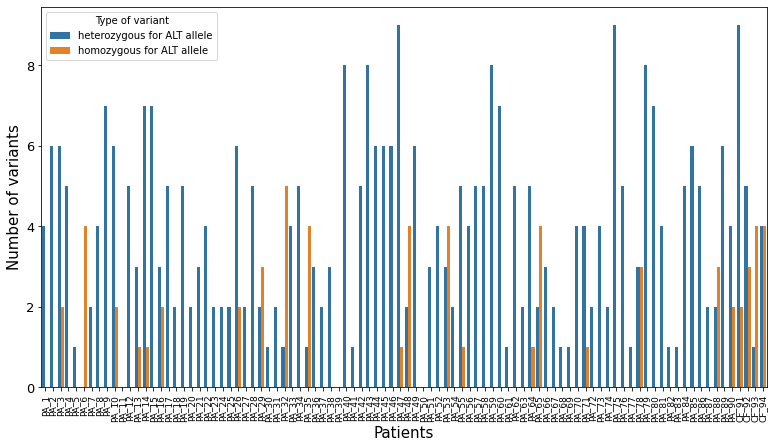

In [74]:
## Plot the number of variants per patient
plt.figure(figsize=(13,7))
sns.barplot('index', "value", hue = "Type of variant", data = counts_of_variants2)
plt.xticks(rotation = 90, size = 9)
plt.yticks(size = 13)
plt.xlabel("Patients", size = 15)
plt.ylabel("Number of variants", size = 15)
plt.savefig("Variants_per_patient.pdf")

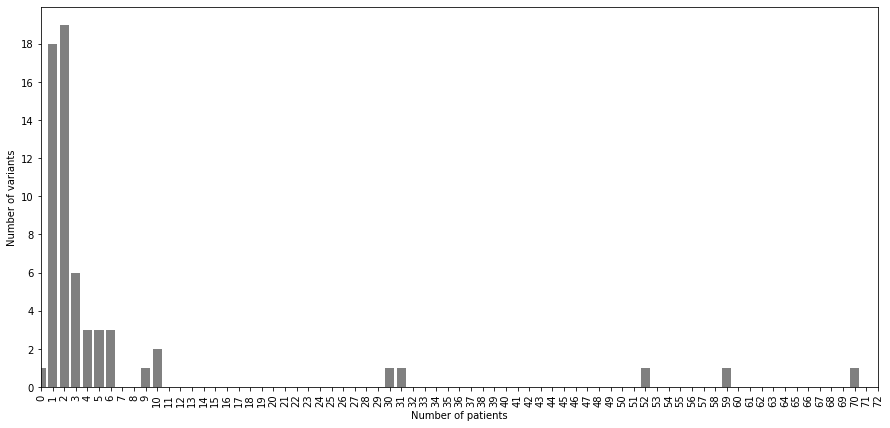

In [199]:
##Plot cumulative number of patients and the number of variants they have 
##(only peanut allergy, heterozygous or homozygous variants)
counts_of_patients = pd.DataFrame(list_of_genotypes)


for j in range(0,genotype_table[range(0,90)].T.shape[1]):
        x = []
        for i in range(0,genotype_table[range(0,90)].T.shape[0]):
            x.append(genotype_table[range(0,90)].T.to_numpy()[i][j])
        unique, counts = np.unique(x, return_counts=True)
        Z = "variant" + "_" + str(j+1)
        y = np.asarray((unique, counts)).T
        counts_of_patients = pd.merge(counts_of_patients, pd.DataFrame(y).rename({1:Z}, axis = 1), on = 0, \
                                      how = "left")
counts_of_patients = counts_of_patients.set_index(0).fillna(0).T  
counts_of_patients = counts_of_patients[["1/1", "1|1", "0|1", "0/1"]]
counts_of_patients["sum"] = counts_of_patients["1/1"].astype(int) + counts_of_patients["1|1"].astype(int) \
+ counts_of_patients["0/1"].astype(int) + counts_of_patients["0|1"].astype(int)

cum_freq = pd.DataFrame()
for i in range(0,90):
    row=[i, len(counts_of_patients[counts_of_patients["sum"] == i])]
    row = pd.DataFrame(row).T
    cum_freq = pd.concat([cum_freq, row])
from matplotlib.ticker import MaxNLocator
fig = plt.figure(figsize=(15,7))
ax=sns.barplot(cum_freq[0].astype(int), cum_freq[1].astype(int), color = "grey")
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.xlim(0,72)
plt.xticks(rotation=90)
plt.xlabel("Number of patients")
plt.ylabel("Number of variants")
plt.savefig("No.patients_vs_no.variants.pdf")

In [171]:
## Prepare a table to plot distribution of allele freuqency per variant 
## This is to check for normal distribution to choose either one sample t-test or one sample Wilcoxon test
df = pd.DataFrame()
for i in range(0,94):
    genotype_table2 = genotype_table.reset_index()
    column = genotype_table2[i].apply(lambda x: (int(x.replace("|", "/").split("/")[0]) \
                                                 + int(x.replace("|", "/").split("/")[1]))/2 if x != './.' else np.NaN)
    column = pd.DataFrame(column)
    df = pd.concat([df, column], axis=1)

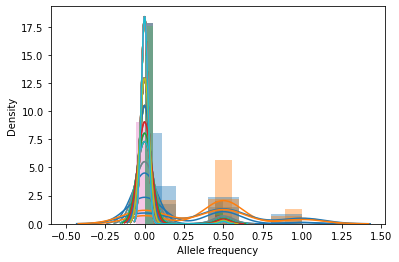

In [76]:
df = df[[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
            17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
            34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
            51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
            68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
            85, 86, 87, 88, 89]]
for i in range(0,60):
    sns.distplot(df.T[i])
    plt.xlabel("Allele frequency")

In [77]:
##Preform one sample t-test 
## comparing the data for each variant from PA patients to a single baseline value from gnomad

from scipy import stats
df_ttest = pd.DataFrame()
table_sub2 = table_sub1.reset_index()
for i in range(0,60):
    tstat,pvalue = stats.ttest_1samp(df.T[i], table_sub2["AF_nfe_gnomad"][i])
    row = [table_sub2["POS"][i], table_sub2["ANN[*].HGVS_C"][i], tstat, pvalue]
    row = pd.DataFrame([row], columns = ["POS", "ANN[*].HGVS_C", "stat", "p-value"])
    df_ttest = df_ttest.append(row)

In [78]:
##Preform one sample Wilcoxon test
## using the data for each variant from PA patients and a single baseline value from gnomad

import numpy as np
from scipy.stats import wilcoxon as wil

df_Wilcoxon = pd.DataFrame()
for i in range(0,60):
    W, p = wil(df.T[i] - table_sub2["AF_nfe_gnomad"][i], alternative = "two-sided")
    row = [table_sub2["POS"][i], table_sub2["ANN[*].HGVS_C"][i], W, p]
    row = pd.DataFrame([row], columns = ["POS", "ANN[*].HGVS_C", "stat", "p-value"])
    df_Wilcoxon = df_Wilcoxon.append(row)

In [79]:
## Print the significantly different from baseline variants that each test found

print(df_ttest[df_ttest["p-value"] <= 0.01])
print(df_Wilcoxon[df_Wilcoxon["p-value"] <= 0.01])

         POS ANN[*].HGVS_C      stat   p-value
0  117535451   c.743+40A>G -2.886292  0.004891
0  117587738   c.1585-1G>A      -inf  0.000000
         POS      ANN[*].HGVS_C    stat       p-value
0  117480087            c.-8G>C   774.0  1.545641e-08
0  117480117            c.23A>G   525.0  7.438449e-12
0  117480209         c.53+62T>C    90.0  1.855656e-19
0  117504290            c.91C>T    90.0  1.855656e-19
0  117504391        c.164+28A>G   179.0  1.063086e-17
0  117509089           c.220C>T   179.0  1.063086e-17
0  117509090           c.221G>A   267.0  4.558889e-16
0  117509093           c.224G>A   855.0  1.318112e-07
0  117531068           c.443T>C    90.0  1.855656e-19
0  117531205        c.489+91A>G   179.0  1.063086e-17
0  117535451        c.743+40A>G   354.0  1.488130e-14
0  117536684        c.869+11C>T   855.0  1.318112e-07
0  117548625      c.1210-15delG   525.0  7.438449e-12
0  117559479          c.1408G>A  1350.0  3.686714e-03
0  117559590  c.1521_1523delCTT   179.0  1.063086

In [80]:
## Choose one final stats table to plot

df_test = df_ttest

In [94]:
## Merge the test results with original allele frequency table and adjust

table_AF2 = pd.merge(df_test[df_test["p-value"] < 0.01], table_AF, on = "ANN[*].HGVS_C", how = "left")
table_AF2["p-value"] = table_AF2["p-value"].apply(lambda x: round(x,4))
table_AF2["stat"] = table_AF2["stat"].apply(lambda x: round(float(x),4) if x != "-inf" else "-inf")
table_AF2 = table_AF2[table_AF2["Data source"] == "PA"]
table_AF2 = table_AF2.reset_index()

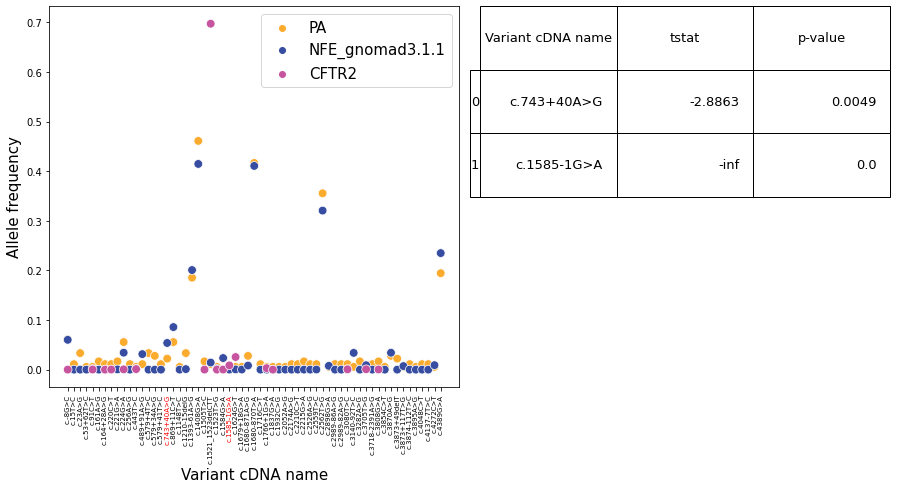

In [95]:
##Plot the significantly different SNPs and add a table of values

from adjustText import adjust_text
color_scheme = ["#FBAC2F","#374DA1","#C7549F"]
fig = plt.figure(figsize=(15,7))
plt.subplots_adjust(wspace = 0.04)
ax1 = fig.add_subplot(121)
ax1 = sns.scatterplot("ANN[*].HGVS_C", "value", hue = "Data source", data = table_AF, palette=color_scheme, s = 75)
plt.xticks(rotation=90, size = 7)
plt.yticks(size = 10)
plt.ylabel("Allele frequency", size = 15)
plt.xlabel("Variant cDNA name", size = 15)
plt.legend(fontsize = 15)
for i in table_sub1.reset_index()[table_sub1.reset_index()["ANN[*].HGVS_C"] \
                                  .isin(table_AF2["ANN[*].HGVS_C"].unique())].index:
    ax1.get_xticklabels()[i].set_color("red")
ax2 = fig.add_subplot(122)
font_size=13
table_AF2.rename({"ANN[*].HGVS_C" : "Variant cDNA name", "stat" : "tstat"}, axis = 1, inplace=True)
fig_table = ax2.table(cellText=table_AF2[["Variant cDNA name", "tstat", "p-value"]].values, \
                  rowLabels = table_AF2[["Variant cDNA name", "tstat", "p-value"]].index, \
                  bbox = [0.01, 0.5, 1, 0.5], \
                  colLabels=table_AF2[["Variant cDNA name", "tstat", "p-value"]].columns)
fig_table.scale(1,2)
fig_table.auto_set_font_size(False)
fig_table.set_fontsize(font_size)
ax2.axis("off")
fig.savefig("AF_frequency_significance.pdf",bbox_inches='tight')
#for i, label in enumerate(list(table_AF2["t-stat"].astype(str) + "," + table_AF2["p-value"].astype(str))):
#    plt.text(table_AF2["ANN[*].HGVS_C"][i], table_AF2["value"][i] + 0.01, label)
#ts = []
#for i, label in enumerate(list(table_AF2["t-stat"].astype(str) + "," + table_AF2["p-value"].astype(str))):
#    ts.append(plt.text(table_AF2["ANN[*].HGVS_C"][i], table_AF2["value"][i] + 0.3, label))

In [ ]:
table_v1 = pd.merge(table, df_ttest, on = ['POS', 'ANN[*].HGVS_C'], how = "left").fillna(".") \
.rename({"stat": "ttest.tscore", "p-value" : "ttest.pvalue"}, axis = 1)
table_v1 = pd.merge(table_v1, df_Wilcoxon, on = ['POS', 'ANN[*].HGVS_C'], how = "left").fillna(".") \
.rename({"stat": "Wilcoxon.score", "p-value" : "Wilcoxon.pvalue"}, axis = 1)
table_v1

In [ ]:
table_v1.to_csv("final.summary.table.clinvar.stats.txt", index = False, sep = "\t")